# Interactive Fitter

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

# Functions

In [2]:
def gaussian(x, A, x0, sigma):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))

def voigt(x, A, x0, sigma, gamma):
    return A * voigt_profile(x - x0, sigma, gamma) / voigt_profile(0, sigma, gamma)

def linear(x, k, b):
    return k * x + b
    
def linear_2points(x, x1, y1, x2, y2):
    k = (y2 - y1) / (x2 - x1)
    b = y1 - k * x1

    return linear(x, k, b)

In [3]:
func_lib = {
    'gaussian': gaussian,
    'voigt': voigt
}

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets, VBox, HBox, Layout
from IPython.display import display
from scipy.optimize import curve_fit
from collections import OrderedDict
import inspect

class Fitter:
    def __init__(self, x, y, lib):
        self.x = x
        self.y = y
        self.lib = lib
        self.comps = OrderedDict()
        self.colors = plt.cm.tab10(np.linspace(0, 1, 10))
        self.setup_ui()
        
    def setup_ui(self):
        self.selector = widgets.Dropdown(options=list(self.lib.keys()), description='Функция:')
        self.add_btn = widgets.Button(description='Добавить', button_style='success')
        self.add_btn.on_click(self.add)
        self.fit_btn = widgets.Button(description='Фитить', button_style='primary')
        self.fit_btn.on_click(self.fit)
        
        self.comps_box = widgets.VBox([])
        self.out = widgets.Output()
        
        display(VBox([HBox([self.selector, self.add_btn, self.fit_btn]), self.comps_box, self.out]))
        self.plot()
        
    def add(self, _):
        name = self.selector.value
        func = self.lib[name]
        
        sig = inspect.signature(func)
        params = [p for p in sig.parameters if p != 'x']
        
        widgs = []
        for p in params:
            w = widgets.FloatText(value=1.0, description=f'{p}:', layout=Layout(width='150px'))
            w.observe(self.plot, 'value')
            widgs.append(w)
        
        cb = widgets.Checkbox(value=True, description='показать', layout=Layout(width='90px'))
        cb.observe(self.plot, 'value')
        
        rem = widgets.Button(description='✖', layout=Layout(width='40px'), button_style='danger')
        
        comp_id = len(self.comps)
        self.comps[comp_id] = {
            'name': name, 'func': func, 'params': widgs, 'enabled': cb,
            'color': self.colors[comp_id % len(self.colors)]
        }
        
        rem.on_click(lambda _, cid=comp_id: self.remove(cid))
        
        self.comps_box.children += (HBox([widgets.HTML(f"<b>{name}</b>", layout=Layout(width='100px'))] + widgs + [cb, rem]),)
        self.plot()
        
    def remove(self, cid):
        del self.comps[cid]
        children = []
        for cid, c in self.comps.items():
            children.append(HBox([widgets.HTML(f"<b>{c['name']}</b>", layout=Layout(width='100px'))] + 
                                c['params'] + [c['enabled'], 
                                widgets.Button(description='✖', layout=Layout(width='40px'), button_style='danger')]))
        self.comps_box.children = tuple(children)
        self.plot()
        
    def model(self, x, *params):
        y = np.zeros_like(x)
        idx = 0
        for c in self.comps.values():
            if c['enabled'].value:
                n = len(c['params'])
                y += c['func'](x, *params[idx:idx+n])
                idx += n
        return y
        
    def plot(self, _=None):
        self.out.clear_output(wait=True)
        with self.out:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})
            
            ax1.plot(self.x, self.y, 'k.', markersize=2, label='data')
            
            y_total = np.zeros_like(self.x)
            for c in self.comps.values():
                if c['enabled'].value:
                    p = [w.value for w in c['params']]
                    yc = c['func'](self.x, *p)
                    y_total += yc
                    ax1.plot(self.x, yc, '--', color=c['color'], alpha=0.7, label=c['name'])
            
            ax1.plot(self.x, y_total, 'r-', linewidth=2, label='sum')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            ax2.plot(self.x, self.y - y_total, 'b-')
            ax2.axhline(0, color='k', ls='--', lw=0.5)
            ax2.grid(True, alpha=0.3)
            ax2.set_xlabel('x')
            
            plt.tight_layout()
            plt.show()
            
    def fit(self, _):
        p0 = []
        for c in self.comps.values():
            if c['enabled'].value:
                p0 += [w.value for w in c['params']]
        
        if not p0:
            return
            
        popt, _ = curve_fit(self.model, self.x, self.y, p0=p0)
        
        idx = 0
        for c in self.comps.values():
            if c['enabled'].value:
                n = len(c['params'])
                for j, w in enumerate(c['params']):
                    w.value = popt[idx + j]
                idx += n
        
        self.plot()

    def integrals(self):
        """Возвращает список площадей под каждой компонентой"""
        areas = []
        for c in self.comps.values():
            if c['enabled'].value:
                p = [w.value for w in c['params']]
                yc = c['func'](self.x, *p)
                areas.append(np.trapz(yc, self.x))
        return areas

    def get_params(self):
        """Экспортирует параметры всех компонент"""
        params = []
        for c in self.comps.values():
            if c['enabled'].value:
                params.append({
                    'name': c['name'],
                    'params': [w.value for w in c['params']]
                })
        return params
    
    def set_params(self, params):
        """Импортирует параметры в новый фиттер"""
        for p in params:
            self.selector.value = p['name']
            self.add(None)
            last_id = len(self.comps) - 1
            for w, val in zip(self.comps[last_id]['params'], p['params']):
                w.value = val

# Analysis

'PCL_M4_100ms_1m_1'

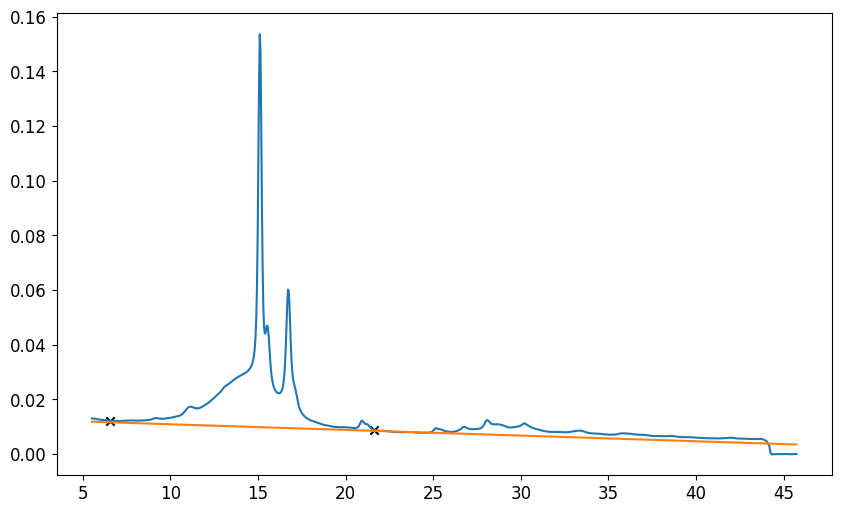

In [5]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00108_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 25
r = 400

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.95

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

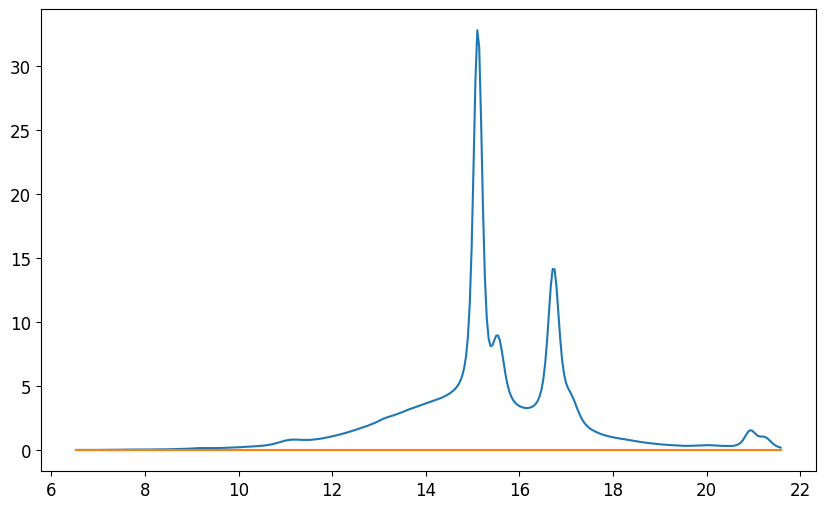

In [6]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M4 = X
Y_M4 = Y * X ** 2

In [7]:
f = Fitter(X_M4, Y_M4, func_lib)

In [8]:
1 + 1

2